<a href="https://colab.research.google.com/github/Ayush-Gole8/DeepLearning/blob/main/23102A0005_DL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TRAINING BIDIRECTIONAL LSTM...

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.1389 - loss: 1.7951 - val_accuracy: 0.0833 - val_loss: 1.7925
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1875 - loss: 1.7881 - val_accuracy: 0.1111 - val_loss: 1.7930
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2222 - loss: 1.7830 - val_accuracy: 0.1111 - val_loss: 1.7906
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2847 - loss: 1.7724 - val_accuracy: 0.1111 - val_loss: 1.7888
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.2500 - loss: 1.7591 - val_accuracy: 0.1111 - val_loss: 1.7850
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3542 - loss: 1.7369 - val_accuracy: 0.3889 - val_loss: 1.7772
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4583 - loss: 1.6961 - val_accuracy: 0.3889 - val_loss: 1.7624
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5000

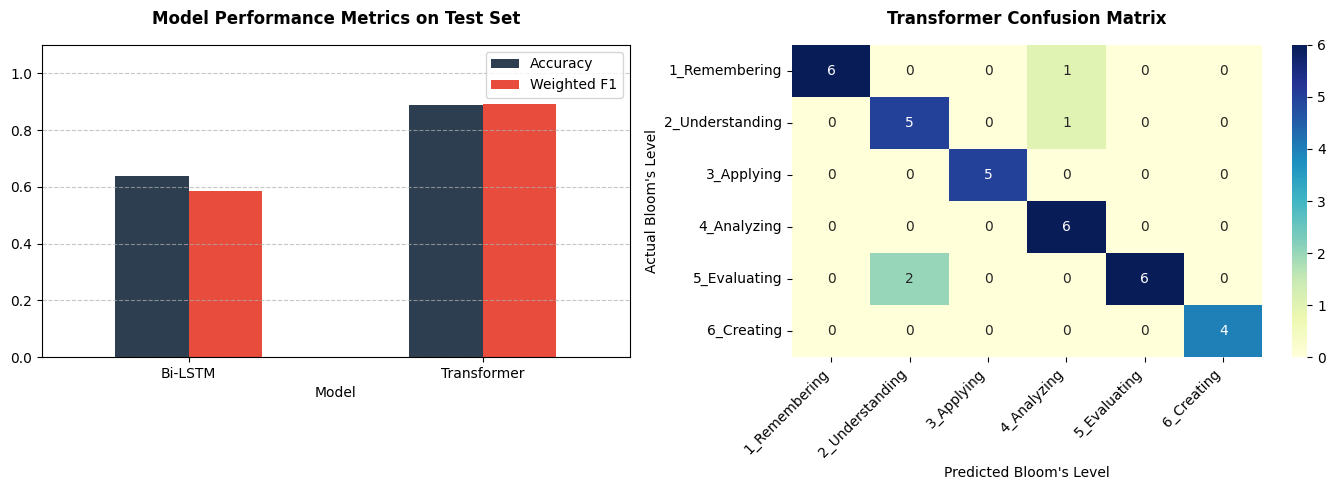

In [9]:
# ==========================================
# AUTOMATIC QUESTION PAPER CATEGORIZATION
# BLOOM'S TAXONOMY - LSTM vs TRANSFORMER (FINAL FIX)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, Input, GlobalAveragePooling1D,
                                     LayerNormalization, MultiHeadAttention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# HYPERPARAMETER CONFIGURATION
# ==========================================
CONFIG = {
    "MAX_VOCAB_SIZE": 5000,
    "MAX_SEQ_LENGTH": 25,
    "EMBEDDING_DIM": 64,
    "LSTM_UNITS": 32,
    "TRANSFORMER_HEADS": 4,
    "TRANSFORMER_FF_DIM": 64,
    "DROPOUT_RATE": 0.3,
    "BATCH_SIZE": 8,
    "EPOCHS": 100,
    "LEARNING_RATE": 0.0005,
    "TEST_SIZE": 0.2,
    "PATIENCE": 20,
    "RANDOM_SEED": 42
}

tf.random.set_seed(CONFIG["RANDOM_SEED"])
np.random.seed(CONFIG["RANDOM_SEED"])

# ==========================================
# 1. DATA PREPARATION
# ==========================================
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

data = {
    "Question": [
        # 1. Remembering (30)
        "Define the concept of machine learning.", "List the capitals of all 50 US states.",
        "Recall the formula for the area of a circle.", "Identify the main characters in the story.",
        "Name the primary colors in the RGB scale.", "State Newton's first law of motion.",
        "What is the chemical symbol for gold?", "Who wrote the novel Pride and Prejudice?",
        "Match the historical figures to their corresponding birth dates.", "Retrieve the definition of an isotope.",
        "State the capital of Japan.", "List the planets in the solar system.",
        "Define the term inflation in economics.", "Identify the author of the poem The Raven.",
        "Recall the year the Magna Carta was signed.", "Who discovered penicillin?",
        "What is the capital of Australia?", "List the primary stages of mitosis.",
        "Define the term velocity.", "Name the first president of the United States.",
        "Recall the boiling point of water.", "State the formula for kinetic energy.",
        "Identify the largest ocean on Earth.", "Match the countries to their continents.",
        "Retrieve the publication date of 1984.", "List the bones in the human arm.",
        "What is the square root of 144?", "Name the inventor of the telephone.",
        "Define photosynthesis.", "Recall the colors of the rainbow.",

        # 2. Understanding (30)
        "Explain how a combustion engine works.", "Interpret the meaning of this poetry stanza.",
        "Summarize the plot of the novel.", "Discuss the causes of the French Revolution.",
        "Classify these animals into mammals and reptiles.", "Outline the steps in the scientific method.",
        "Describe the process of photosynthesis in your own words.", "Explain the difference between weather and climate.",
        "Summarize the main argument of the research paper.", "Paraphrase the president's inauguration speech.",
        "Categorize the following expenses as fixed or variable.", "Discuss the themes of isolation in the text.",
        "Give an example of a symbiotic relationship.", "Translate this French idiom into its English equivalent.",
        "Clarify the concept of supply and demand using a real-world scenario.", "Explain the water cycle.",
        "Summarize the ending of the movie.", "Discuss the impact of the Industrial Revolution.",
        "Classify these foods into macronutrient groups.", "Describe the function of the human heart.",
        "Paraphrase this complex legal text.", "Categorize the different types of clouds.",
        "Translate this Spanish paragraph into English.", "Clarify how a democratic government operates.",
        "Give an example of a renewable energy source.", "Explain why the sky appears blue.",
        "Outline the main events of World War II.", "Interpret the data shown in this pie chart.",
        "Discuss the cultural significance of the festival.", "Summarize the key findings of the geological report.",

        # 3. Applying (30)
        "Apply the Pythagorean theorem to find the missing side.", "Calculate the compound interest for the given principal.",
        "Demonstrate how to safely use a bunsen burner.", "Illustrate the data using a bar chart.",
        "Solve the differential equation.", "Execute the Python script to process the data.",
        "Use the quadratic formula to solve for x.", "Implement a sorting algorithm in C++.",
        "Predict the trajectory of the projectile given its initial velocity.", "Employ negotiation tactics in a mock interview.",
        "Graph the linear equation y = mx + b.", "Calculate the standard deviation of the provided dataset.",
        "Show how you would apply first aid for a severe burn.", "Modify the recipe to serve twelve people instead of four.",
        "Operate the machinery according to the safety manual.", "Apply Newton's second law to calculate force.",
        "Demonstrate the proper CPR technique.", "Solve for y in the equation 2y + 5 = 15.",
        "Execute the SQL query to fetch user data.", "Use a compass to draw a perfect circle.",
        "Calculate the BMI of a person weighing 70kg.", "Implement a binary search in Java.",
        "Graph the exponential growth of the bacteria population.", "Modify the code to fix the runtime error.",
        "Predict the outcome of the chemical reaction.", "Employ active listening during the conflict mediation.",
        "Illustrate the concept of fractions using a pizza diagram.", "Show how to tie a bowline knot.",
        "Operate a manual transmission vehicle safely.", "Apply the principles of design to format the marketing poster.",

        # 4. Analyzing (30)
        "Analyze the impact of climate change on coastal cities.", "Contrast the economic policies of the two countries.",
        "Deconstruct the arguments made in the political essay.", "Examine the chemical composition of this rock.",
        "Investigate the relationship between supply and demand.", "Differentiate between a virus and a bacteria.",
        "Compare the architectural styles of the Renaissance and Gothic periods.", "Break down the components of a biological cell.",
        "Outline the logical fallacies in the debate transcript.", "Distinguish between correlation and causation in this study.",
        "Analyze the structural integrity of the bridge design.", "Examine the motives of the protagonist in the final chapter.",
        "Point out the flaws in the experimental setup.", "Contrast the principles of classical mechanics with quantum physics.",
        "Deconstruct the marketing strategy used in the commercial.", "Analyze the motives behind the character's betrayal.",
        "Contrast the effects of inflation and deflation.", "Deconstruct the arguments in the defense attorney's closing statement.",
        "Examine the cellular structure of a plant leaf under a microscope.", "Investigate the root cause of the server system failure.",
        "Differentiate between a hurricane and a tornado.", "Compare the core themes of Hamlet and Macbeth.",
        "Break down the annual budget into specific departmental expenses.", "Distinguish between hardware and software components.",
        "Point out the inconsistencies in the witness's testimony.", "Analyze the syntax of the provided Python script.",
        "Examine the role of mitochondria in the human cell.", "Contrast direct democracy and autocracy.",
        "Deconstruct the visual elements of the renaissance painting.", "Investigate the statistical link between diet and heart disease.",

        # 5. Evaluating (30)
        "Evaluate the effectiveness of the new marketing campaign.", "Critique the methodology used in this research paper.",
        "Assess the risks associated with the proposed investment.", "Judge the quality of the artwork based on specific criteria.",
        "Defend your position on the ethical implications of AI.", "Argue for or against mandatory voting.",
        "Review the software code for security vulnerabilities.", "Justify the decision to allocate budget to the IT department.",
        "Appraise the value of the historical artifact.", "Rank the proposed solutions from most to least viable.",
        "Defend the use of nuclear energy in a public debate.", "Validate the results of the AB testing experiment.",
        "Critique the character development in the film sequel.", "Assess the long-term sustainability of this practice.",
        "Weigh the pros and cons of implementing universal basic income.", "Evaluate the performance of the latest smartphone model.",
        "Critique the architectural design of the new city museum.", "Assess the validity of the primary historical source.",
        "Judge whether the penalty was fair based on the official rulebook.", "Defend the use of animal testing in life-saving medical research.",
        "Argue for the implementation of a four-day workweek.", "Review the restaurant's menu for dietary inclusivity and allergies.",
        "Justify the CEO's decision to downsize the company during the recession.", "Appraise the environmental impact of the new hydroelectric dam.",
        "Rank the candidates based on their technical interview performance.", "Validate the mathematical proof provided by the graduate student.",
        "Critique the use of lighting in the theater production.", "Assess the credibility of the breaking news article.",
        "Weigh the benefits and drawbacks of transitioning to electric vehicles.", "Evaluate the efficiency of the new supply chain routing algorithm.",

        # 6. Creating (30)
        "Design a new sustainable packaging solution.", "Create a marketing plan for the product launch.",
        "Develop a mobile app for tracking daily fitness.", "Compose a poem about the ocean.",
        "Formulate a hypothesis based on your observations.", "Invent a device that solves a common household problem.",
        "Write a short story set in a dystopian future.", "Construct a 3D model of a modern smart home.",
        "Propose a new policy to reduce urban traffic congestion.", "Assemble a team of experts for the upcoming space mission.",
        "Design a comprehensive curriculum for a coding bootcamp.", "Generate a strategic business plan for a startup.",
        "Formulate a chemical compound that resists high temperatures.", "Choreograph a dance routine to a classical symphony.",
        "Pitch an original concept for a reality television show.", "Design a user interface for a new social media platform.",
        "Create a weekly meal plan for a vegan competitive athlete.", "Develop a theoretical physics model for time travel.",
        "Compose an original piece of sheet music for grand piano.", "Formulate a new dinner recipe using only five ingredients.",
        "Invent a board game that teaches financial literacy to children.", "Write a script for a 30-second radio commercial.",
        "Construct a makeshift shelter using natural forest materials.", "Propose a workable solution to reduce plastic waste in the ocean.",
        "Assemble a customized PC build tailored for high-end gaming.", "Design a modern logo for a sustainable clothing brand.",
        "Generate a unique plot concept for a sci-fi novel.", "Formulate a strategy to win the upcoming chess tournament.",
        "Choreograph a martial arts fight sequence for a short film.", "Pitch a digital campaign idea to significantly increase voter turnout."
    ],
    "Bloom_Level": (
        ["1_Remembering"] * 30 + ["2_Understanding"] * 30 +
        ["3_Applying"] * 30 + ["4_Analyzing"] * 30 +
        ["5_Evaluating"] * 30 + ["6_Creating"] * 30
    )
}
df = pd.DataFrame(data)

# ==========================================
# 2. PREPROCESSING & VECTORIZATION
# ==========================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

df['Cleaned_Question'] = df['Question'].apply(preprocess_text)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Bloom_Level'])
NUM_CLASSES = len(label_encoder.classes_)

tokenizer = Tokenizer(num_words=CONFIG["MAX_VOCAB_SIZE"], oov_token="<OOV>")
tokenizer.fit_on_texts(df['Cleaned_Question'])
X_padded = pad_sequences(tokenizer.texts_to_sequences(df['Cleaned_Question']),
                         maxlen=CONFIG["MAX_SEQ_LENGTH"], padding='post')

X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=CONFIG["TEST_SIZE"], random_state=CONFIG["RANDOM_SEED"])

# THE FIX: Two separate EarlyStopping instances!
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=CONFIG["PATIENCE"], restore_best_weights=True, verbose=1)
early_stop_trans = EarlyStopping(monitor='val_loss', patience=CONFIG["PATIENCE"], restore_best_weights=True, verbose=1)

# ==========================================
# 3. BIDIRECTIONAL LSTM MODEL
# ==========================================
print("==========================================")
print("TRAINING BIDIRECTIONAL LSTM...")
print("==========================================\n")
lstm_model = Sequential([
    Embedding(input_dim=CONFIG["MAX_VOCAB_SIZE"], output_dim=CONFIG["EMBEDDING_DIM"]),
    Bidirectional(LSTM(CONFIG["LSTM_UNITS"], return_sequences=False)),
    Dropout(CONFIG["DROPOUT_RATE"]),
    Dense(32, activation='relu'),
    Dropout(CONFIG["DROPOUT_RATE"]),
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer=Adam(learning_rate=CONFIG["LEARNING_RATE"], clipnorm=1.0),
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=CONFIG["EPOCHS"],
    batch_size=CONFIG["BATCH_SIZE"],
    validation_data=(X_test, y_test),
    callbacks=[early_stop_lstm], # Using LSTM's specific callback
    verbose=1
)
print("\nLSTM Training Complete.\n")

# ==========================================
# 4. TRANSFORMER MODEL
# ==========================================
print("==========================================")
print("TRAINING TRANSFORMER MODEL...")
print("==========================================\n")
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=CONFIG["DROPOUT_RATE"]):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = Sequential([Dense(ff_dim, activation="relu"), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        return self.layernorm2(out1 + self.dropout2(self.ffn(out1), training=training))

class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        return self.token_emb(x) + self.pos_emb(tf.range(start=0, limit=tf.shape(x)[-1], delta=1))

inputs = Input(shape=(CONFIG["MAX_SEQ_LENGTH"],))
x = TokenAndPositionEmbedding(CONFIG["MAX_SEQ_LENGTH"], CONFIG["MAX_VOCAB_SIZE"], CONFIG["EMBEDDING_DIM"])(inputs)
x = TransformerBlock(CONFIG["EMBEDDING_DIM"], CONFIG["TRANSFORMER_HEADS"], CONFIG["TRANSFORMER_FF_DIM"])(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(CONFIG["DROPOUT_RATE"])(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

transformer_model = Model(inputs=inputs, outputs=outputs)
transformer_model.compile(loss="sparse_categorical_crossentropy",
                          optimizer=Adam(learning_rate=CONFIG["LEARNING_RATE"], clipnorm=1.0),
                          metrics=["accuracy"])

transformer_history = transformer_model.fit(
    X_train, y_train,
    epochs=CONFIG["EPOCHS"],
    batch_size=CONFIG["BATCH_SIZE"],
    validation_data=(X_test, y_test),
    callbacks=[early_stop_trans], # Using Transformer's specific callback!
    verbose=1
)
print("\nTransformer Training Complete.\n")

# ==========================================
# 5. HEAD-TO-HEAD COMPARISON
# ==========================================
def get_metrics(model, name):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    return name, acc, f1, y_pred

lstm_name, lstm_acc, lstm_f1, lstm_pred = get_metrics(lstm_model, "Bi-LSTM")
trans_name, trans_acc, trans_f1, trans_pred = get_metrics(transformer_model, "Transformer")

results_df = pd.DataFrame([
    {"Model": lstm_name, "Accuracy": lstm_acc, "Weighted F1": lstm_f1},
    {"Model": trans_name, "Accuracy": trans_acc, "Weighted F1": trans_f1}
])

print("\n==========================================")
print("FINAL METRICS COMPARISON")
print("==========================================")
print(results_df.to_string(index=False))

# Plot Comparison Graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Bar Chart of Metrics
results_df.plot(x="Model", y=["Accuracy", "Weighted F1"], kind="bar", ax=ax[0], color=['#2c3e50', '#e74c3c'])
ax[0].set_ylim(0, 1.1)
ax[0].set_title("Model Performance Metrics on Test Set", pad=15, fontweight='bold')
ax[0].tick_params(axis='x', rotation=0)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graph 2: Transformer Confusion Matrix
sns.heatmap(confusion_matrix(y_test, trans_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax[1])
ax[1].set_title("Transformer Confusion Matrix", pad=15, fontweight='bold')
ax[1].set_ylabel("Actual Bloom's Level")
ax[1].set_xlabel("Predicted Bloom's Level")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()